In [1]:
# !pip -q install tensorflow==2.16.1  # (Uncomment if your Colab TF is old)
import os, random, time, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# GPU check
print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Matplotlib defaults (keep it simple)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True


TensorFlow: 2.19.0
GPU Available: []


In [2]:
# IMDB is built-in and returns integer-encoded sequences
NUM_WORDS = 20000
MAXLEN = 250

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)

# Pad/truncate to fixed length
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test  = keras.preprocessing.sequence.pad_sequences(x_test,  maxlen=MAXLEN)

# Train/Val split
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (20000, 250), Val: (5000, 250), Test: (25000, 250)


In [3]:
BATCH_SIZE = 128
EPOCHS = 6
EMBED_DIM = 128

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=1, factor=0.5, verbose=1),
]

def train_and_eval(model, name):
    print(f"\n===== Training {name} =====")
    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2
    )
    train_time = time.time() - t0

    print(f"\nEvaluating {name} on Test:")
    test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = (model.predict(x_test, batch_size=BATCH_SIZE, verbose=0).ravel() >= 0.5).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    return {
        "name": name,
        "model": model,
        "history": history.history,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "cm": cm,
        "train_time_sec": train_time,
        "params": model.count_params(),
    }

def plot_history(histories, metric="accuracy"):
    plt.figure()
    for h in histories:
        plt.plot(h["history"][f"val_{metric}"], label=f'{h["name"]} (val)')
    plt.xlabel("Epoch"); plt.ylabel(metric.capitalize()); plt.title(f"Validation {metric.capitalize()}")
    plt.legend(); plt.show()

def show_cm(cm, title="Confusion Matrix"):
    import itertools
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title); plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["neg","pos"]); plt.yticks(tick_marks, ["neg","pos"])
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout(); plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.show()


In [4]:
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(NUM_WORDS, EMBED_DIM, input_length=MAXLEN)(inputs)
x = layers.GRU(64)(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_a = keras.Model(inputs, outputs, name="GRU_64_single")
model_a.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_a.summary()

res_a = train_and_eval(model_a, "GRU-64 Single")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "GRU_64_single"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,473 (9.92 MB)

 Trainable params: 2,601,473 (9.92 MB)

 Non-trainable params: 0 (0.00 B)


===== Training GRU-64 Single =====
Epoch 1/6
157/157 - 104s - 660ms/step - accuracy: 0.7365 - loss: 0.5007 - val_accuracy: 0.8540 - val_loss: 0.3474 - learning_rate: 1.0000e-03
Epoch 2/6

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 - 130s - 828ms/step - accuracy: 0.9071 - loss: 0.2350 - val_accuracy: 0.8680 - val_loss: 0.4243 - learning_rate: 1.0000e-03
Epoch 3/6

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 - 90s - 571ms/step - accuracy: 0.9512 - loss: 0.1373 - val_accuracy: 0.8726 - val_loss: 0.4128 - learning_rate: 5.0000e-04
Epoch 4/6

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
157/157 - 89s - 570ms/step - accuracy: 0.9734 - loss: 0.0820 - val_accuracy: 0.8688 - val_loss: 0.3906 - learning_rate: 2.5000e-04
Epoch 5/6

Epoch 5: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
157/157 - 142s - 906ms/step - accuracy: 0.9836 - loss: 0.0547 - val_accuracy: 0.8

In [5]:
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(NUM_WORDS, EMBED_DIM, input_length=MAXLEN)(inputs)
x = layers.GRU(64, dropout=0.3, recurrent_dropout=0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_b = keras.Model(inputs, outputs, name="GRU_64_dropout")
model_b.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_b.summary()

res_b = train_and_eval(model_b, "GRU-64 + Dropout")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "GRU_64_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,473 (9.92 MB)

 Trainable params: 2,601,473 (9.92 MB)

 Non-trainable params: 0 (0.00 B)


===== Training GRU-64 + Dropout =====
Epoch 1/6
157/157 - 94s - 600ms/step - accuracy: 0.6786 - loss: 0.5851 - val_accuracy: 0.7738 - val_loss: 0.4695 - learning_rate: 1.0000e-03
Epoch 2/6
157/157 - 88s - 559ms/step - accuracy: 0.8360 - loss: 0.3841 - val_accuracy: 0.8148 - val_loss: 0.4217 - learning_rate: 1.0000e-03
Epoch 3/6

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 - 142s - 904ms/step - accuracy: 0.8680 - loss: 0.3177 - val_accuracy: 0.8088 - val_loss: 0.4419 - learning_rate: 1.0000e-03
Epoch 4/6

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 - 88s - 559ms/step - accuracy: 0.9191 - loss: 0.2187 - val_accuracy: 0.8236 - val_loss: 0.4559 - learning_rate: 5.0000e-04
Epoch 5/6

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
157/157 - 147s - 937ms/step - accuracy: 0.9381 - loss: 0.1736 - val_accuracy: 0.8216 - val_loss: 0.4691 - learning_rate: 2.5000e-04
Epoch 6/6

Epoch 6: Red

In [6]:
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(NUM_WORDS, EMBED_DIM, input_length=MAXLEN)(inputs)
x = layers.GRU(64, return_sequences=True)(x)
x = layers.GRU(32)(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_c = keras.Model(inputs, outputs, name="GRU_stacked_64_32")
model_c.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_c.summary()

res_c = train_and_eval(model_c, "Stacked GRU (64→32)")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "GRU_stacked_64_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 250, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,608,833 (9.95 MB)

 Trainable params: 2,608,833 (9.95 MB)

 Non-trainable params: 0 (0.00 B)


===== Training Stacked GRU (64→32) =====
Epoch 1/6
157/157 - 127s - 807ms/step - accuracy: 0.7595 - loss: 0.4752 - val_accuracy: 0.8612 - val_loss: 0.3314 - learning_rate: 1.0000e-03
Epoch 2/6

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 - 126s - 802ms/step - accuracy: 0.9108 - loss: 0.2305 - val_accuracy: 0.8404 - val_loss: 0.3657 - learning_rate: 1.0000e-03
Epoch 3/6

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 - 141s - 899ms/step - accuracy: 0.9495 - loss: 0.1424 - val_accuracy: 0.8618 - val_loss: 0.3794 - learning_rate: 5.0000e-04
Epoch 4/6

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
157/157 - 146s - 927ms/step - accuracy: 0.9686 - loss: 0.0937 - val_accuracy: 0.8550 - val_loss: 0.4049 - learning_rate: 2.5000e-04
Epoch 5/6

Epoch 5: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
157/157 - 124s - 791ms/step - accuracy: 0.9822 - loss: 0.0620 - val_accur

In [7]:
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(NUM_WORDS, EMBED_DIM, input_length=MAXLEN)(inputs)
x = layers.Bidirectional(layers.GRU(64))(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_d = keras.Model(inputs, outputs, name="BiGRU_64")
model_d.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_d.summary()

res_d = train_and_eval(model_d, "Bidirectional GRU-64")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiGRU_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,642,817 (10.08 MB)

 Trainable params: 2,642,817 (10.08 MB)

 Non-trainable params: 0 (0.00 B)


===== Training Bidirectional GRU-64 =====
Epoch 1/6
157/157 - 182s - 1s/step - accuracy: 0.7435 - loss: 0.4888 - val_accuracy: 0.8590 - val_loss: 0.3365 - learning_rate: 1.0000e-03
Epoch 2/6

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 - 209s - 1s/step - accuracy: 0.9040 - loss: 0.2420 - val_accuracy: 0.8628 - val_loss: 0.3440 - learning_rate: 1.0000e-03
Epoch 3/6

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 - 176s - 1s/step - accuracy: 0.9464 - loss: 0.1522 - val_accuracy: 0.8726 - val_loss: 0.3684 - learning_rate: 5.0000e-04
Epoch 4/6

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
157/157 - 201s - 1s/step - accuracy: 0.9654 - loss: 0.1004 - val_accuracy: 0.8624 - val_loss: 0.3781 - learning_rate: 2.5000e-04
Epoch 5/6

Epoch 5: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
157/157 - 176s - 1s/step - accuracy: 0.9812 - loss: 0.0616 - val_accuracy: 0.8658 - 

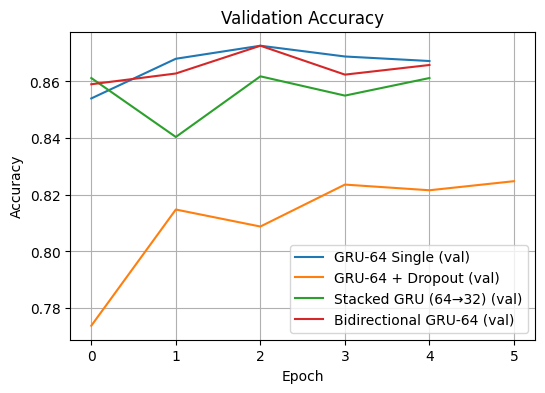

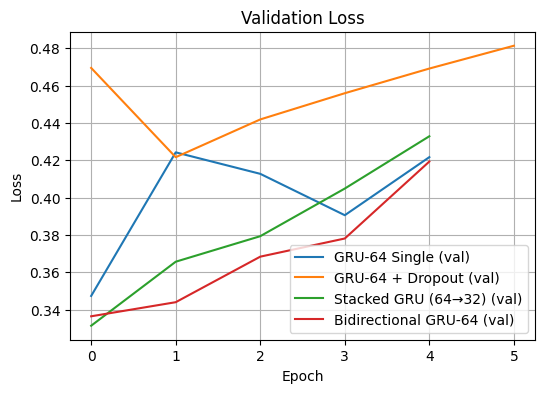

In [8]:
results = [res_a, res_b, res_c, res_d]

# Validation Accuracy
plot_history(results, metric="accuracy")
# Validation Loss
plot_history(results, metric="loss")



=== Bidirectional GRU-64 ===
Test Acc: 0.8628 | Test Loss: 0.3882


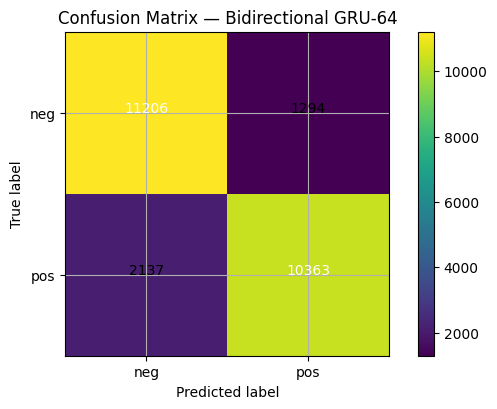

Precision (pos): 0.8890
Recall    (pos): 0.8290
F1        (pos): 0.8580

=== Stacked GRU (64→32) ===
Test Acc: 0.8602 | Test Loss: 0.3799


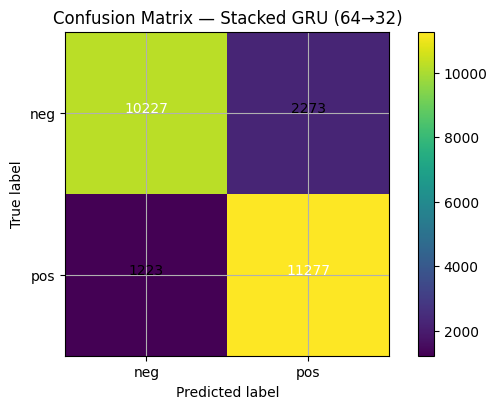

Precision (pos): 0.8323
Recall    (pos): 0.9022
F1        (pos): 0.8658


In [9]:
# Sort by test accuracy
results_sorted = sorted(results, key=lambda r: r["test_acc"], reverse=True)
best = results_sorted[:2]
for r in best:
    print(f"\n=== {r['name']} ===")
    print(f"Test Acc: {r['test_acc']:.4f} | Test Loss: {r['test_loss']:.4f}")
    show_cm(r["cm"], title=f"Confusion Matrix — {r['name']}")
    # Pretty text report
    # (We already computed precision/recall/f1 for class 1; show a quick summary)
    print(f"Precision (pos): {r['precision']:.4f}")
    print(f"Recall    (pos): {r['recall']:.4f}")
    print(f"F1        (pos): {r['f1']:.4f}")


In [10]:
summary_rows = []
for r in results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["params"],
        "Val Best Acc": max(r["history"]["val_accuracy"]),
        "Val Best Loss": min(r["history"]["val_loss"]),
        "Test Acc": r["test_acc"],
        "Test Loss": r["test_loss"],
        "Precision (pos)": r["precision"],
        "Recall (pos)": r["recall"],
        "F1 (pos)": r["f1"],
        "Train Time (s)": r["train_time_sec"],
    })
df = pd.DataFrame(summary_rows).sort_values(by="Test Acc", ascending=False)
df.reset_index(drop=True, inplace=True)
df


,Model,Params,Val Best Acc,Val Best Loss,Test Acc,Test Loss,Precision (pos),Recall (pos),F1 (pos),Train Time (s)
0,Bidirectional GRU-64,2642817,0.8726,0.336487,0.86276,0.388159,0.888994,0.82904,0.857971,944.098724
1,Stacked GRU (64→32),2608833,0.8618,0.331438,0.86016,0.379924,0.832251,0.90216,0.865797,663.556739
2,GRU-64 Single,2601473,0.8726,0.347385,0.85980,0.439613,0.895037,0.81520,0.853255,555.235522
3,GRU-64 + Dropout,2601473,0.8248,0.421678,0.82476,0.471231,0.816827,0.83728,0.826927,647.346354


In [11]:
best_model = max(results, key=lambda r: r["test_acc"])
print("Best by Test Accuracy:", best_model["name"], " — Acc:", round(best_model["test_acc"], 4))

# Save Keras model
save_path = f"/content/{best_model['name'].replace(' ','_')}.keras"
best_model["model"].save(save_path)
print("Saved to:", save_path)


Best by Test Accuracy: Bidirectional GRU-64  — Acc: 0.8628
Saved to: /content/Bidirectional_GRU-64.keras


In [14]:
#Cell A
from tensorflow import keras
best_path = "/content/Bidirectional_GRU-64.keras"
best_model = keras.models.load_model(best_path)
loss, acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Reloaded model — Test Acc: {acc:.4f}, Loss: {loss:.4f}")


Reloaded model — Test Acc: 0.8628, Loss: 0.3882


In [15]:
# Build IMDB index maps
word_index = keras.datasets.imdb.get_word_index()
index_from = 3  # Keras IMDB uses offsets: 0:padding, 1:START, 2:UNK
w2i = {k:(v+index_from) for k,v in word_index.items()}
w2i["<PAD>"] = 0; w2i["<START>"] = 1; w2i["<UNK>"] = 2

def encode_text(s, maxlen=250):
    tokens = keras.preprocessing.text.text_to_word_sequence(s)
    seq = [1]  # <START>
    for t in tokens:
        seq.append(w2i.get(t, 2))  # <UNK> if unseen
    return keras.preprocessing.sequence.pad_sequences([seq], maxlen=maxlen)

def predict_sentiment(texts):
    arr = keras.preprocessing.sequence.pad_sequences([encode_text(t)[0] for t in texts], maxlen=250)
    probs = best_model.predict(arr, verbose=0).ravel()
    for t, p in zip(texts, probs):
        label = "positive" if p>=0.5 else "negative"
        print(f"[{label} | p={p:.3f}] {t}")

# Try a few
predict_sentiment([
    "This movie was absolutely wonderful with great acting and a moving story.",
    "Terrible plot and boring characters. I regret watching this."
])


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[positive | p=0.991] This movie was absolutely wonderful with great acting and a moving story.
[negative | p=0.068] Terrible plot and boring characters. I regret watching this.


In [16]:
# Reverse map to decode integer sequences back to text (approximate)
i2w = {v:k for k,v in w2i.items()}

def decode_review(seq):
    return " ".join(i2w.get(i, "?") for i in seq if i != 0)

# Predictions on test set
y_prob = best_model.predict(x_test, batch_size=128, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

mis_idx = np.where(y_pred != y_test)[0]
print("Misclassified count:", len(mis_idx))

# Show a few misclassified examples
for i in mis_idx[:3]:
    print("\n--- Example", i, "---")
    print("True:", int(y_test[i]), "Pred:", int(y_pred[i]), f"(p={y_prob[i]:.3f})")
    print(decode_review(x_test[i]))


Misclassified count: 3431

--- Example 3 ---
True: 0 Pred: 1 (p=0.878)
<START> i generally love this type of movie however this time i found myself wanting to kick the screen since i can't do that i will just complain about it this was absolutely idiotic the things that happen with the dead kids are very cool but the alive people are absolute idiots i am a grown man pretty big and i can defend myself well however i would not do half the stuff the little girl does in this movie also the mother in this movie is reckless with her children to the point of neglect i wish i wasn't so angry about her and her actions because i would have otherwise enjoyed the flick what a number she was take my advise and fast forward through everything you see her do until the end also is anyone else getting sick of watching movies that are filmed so dark anymore one can hardly see what is being filmed as an audience we are impossibly involved with the actions on the screen so then why the hell can't we have 

ROC AUC: 0.9384


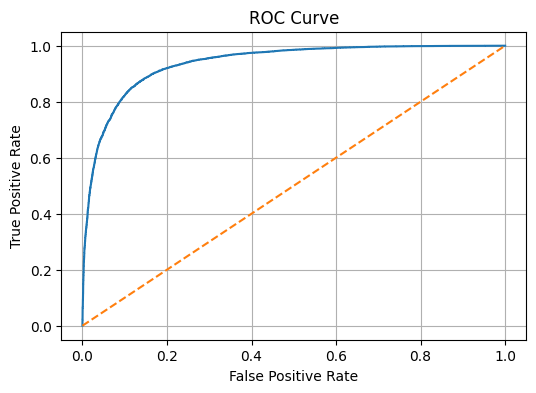

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", round(auc, 4))

fpr, tpr, thr = roc_curve(y_test, y_prob)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [18]:
# Use the 'df' built earlier if present; else rebuild minimal summary
try:
    df.to_csv("/content/gru_comparison_summary.csv", index=False)
    print("Saved: /content/gru_comparison_summary.csv")
except NameError:
    import pandas as pd, json
    row = {
        "Model": "Bidirectional GRU-64",
        "Test Acc": float(acc),
        "Test Loss": float(loss),
        "ROC AUC": float(auc),
        "Params": best_model.count_params()
    }
    df_min = pd.DataFrame([row])
    df_min.to_csv("/content/gru_comparison_summary.csv", index=False)
    print("Saved: /content/gru_comparison_summary.csv")


Saved: /content/gru_comparison_summary.csv


In [22]:
import tensorflow as tf

MAXLEN = 250  # keep consistent with your training

# 1) Create a concrete serving fn with a static, int32 signature
@tf.function(input_signature=[tf.TensorSpec([None, MAXLEN], tf.int32, name="input_ids")])
def serve_fn(x):
    # Cast just in case the saved model expects float; embedding needs int indices
    x = tf.cast(x, tf.int32)
    return best_model(x)

concrete_fn = serve_fn.get_concrete_function()

# 2) Build converter from the concrete function
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn])

# 3) Allow Select TF Ops + keep tensor-list ops (avoids the TensorListReserve error)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,       # built-in TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS          # enable TensorFlow ops fallback
]
converter._experimental_lower_tensor_list_ops = False

# (Optional) enable default optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4) Convert and save
tflite_model = converter.convert()
tflite_path = "/content/Bidirectional_GRU-64_selecttf.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"TFLite saved to: {tflite_path} | Size (KB): {size_kb:.1f}")




TFLite saved to: /content/Bidirectional_GRU-64_selecttf.tflite | Size (KB): 2617.0


In [28]:
import numpy as np, tensorflow as tf

tflite_path = "/content/Bidirectional_GRU-64_selecttf.tflite"
batch = 8  # change this to any batch size you want
sample = x_test[:batch].astype(np.int32)

# Try normal interpreter first; fall back to Flex if needed
try:
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
except Exception as e:
    print("Standard interpreter failed. Trying Flex delegate...", e)
    delegate = tf.lite.load_delegate("libtensorflowlite_flex.so")
    interpreter = tf.lite.Interpreter(
        model_path=tflite_path,
        experimental_delegates=[delegate]
    )
    interpreter.allocate_tensors()

# Get I/O details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ---- Resize input to (batch, 250) if needed ----
# Many TFLite exports default to (1, 250). We make it (batch, 250).
current_shape = input_details[0]["shape"]  # e.g., [1, 250]
if current_shape[0] != batch or current_shape[1] != sample.shape[1]:
    # Use input index (0 for the first input) to resize
    interpreter.resize_tensor_input(0, [batch, sample.shape[1]])
    interpreter.allocate_tensors()
    # Refresh details after realloc
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

# DType alignment
inp_idx = input_details[0]["index"]
expected_dtype = input_details[0]["dtype"]
if sample.dtype != expected_dtype:
    sample = sample.astype(expected_dtype)

# Run inference
interpreter.set_tensor(inp_idx, sample)
interpreter.invoke()
tflite_out = interpreter.get_tensor(output_details[0]["index"]).ravel()

print("Keras probs (first batch):", y_prob[:batch])
print("TFLite probs:", tflite_out)
print("Input shape accepted by TFLite:", input_details[0]["shape"])


Keras probs (first batch): [0.18408433 0.98943806 0.8854749  0.87841773 0.9989104  0.9804783
 0.97787946 0.00863406]
TFLite probs: [0.18154578 0.9894285  0.88513106 0.8773678  0.9989205  0.98064464
 0.977921   0.00854042]
Input shape accepted by TFLite: [  8 250]
